# E-Commerce Sales & Customer Behavior Analysis

### Exploratory Data Analysis (EDA)

**Dataset:** UCI Online Retail Dataset  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

---

## 1. Project Overview

This project analyzes e-commerce transaction data to understand sales
performance, customer behavior, product demand, and purchasing trends.

### Objectives

- Analyze overall sales performance
- Identify top-selling and frequently ordered products
- Analyze customer purchasing behavior
- Identify high-value customers
- Examine monthly and weekly sales trends
- Analyze transaction cancellations
- Identify potential outliers
- Explore relationships between quantity, price, and sales
- Generate actionable business insights and recommendations

## 2. Import Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

## 3. Load the Dataset

In [2]:
df = pd.read_excel("dataset/Online Retail.xlsx")

### Dataset Preview

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

### Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 4. Data Understanding
### 4.1 Dataset Shape

In [76]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 535187
Columns: 8


### 4.2 Column Names

In [85]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

### 4.3 Data Types

In [86]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [9]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### 4.4 Missing Values

In [10]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(5268)

## 5.Data Cleaning
### 5.1 Check and Remove Duplicate Rows

In [12]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:",duplicate_count)

Duplicate rows: 5268


In [13]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(536641, 8)

In [18]:
df[df['Description'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [19]:
df[df['CustomerID'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


### 5.2 handle Missing Values

In [20]:
df = df.dropna(subset=['Description'])

In [21]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133583
Country             0
dtype: int64

### 5.3 Handle Cancelled Transactions

In [22]:
cancelled = df['InvoiceNo'].astype(str).str.startswith('C')
cancelled.sum()

np.int64(9251)

In [23]:
df[cancelled].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [24]:
df[cancelled]['Quantity'].describe()

count     9251.000000
mean       -29.787050
std       1147.997592
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64

## 9. Cancellation Analysis

In [25]:
cancellation_percentage = (cancelled.sum() / len(df)) * 100
print("Cancelled transactions:", cancelled.sum())
print("Cancellation percentage:", cancellation_percentage)

Cancelled transactions: 9251
Cancellation percentage: 1.7285546920982757


In [26]:
df_clean = df[~cancelled].copy()

In [27]:
df_clean.shape

(525936, 8)

In [28]:
(df_clean['Quantity'] <= 0).sum()

np.int64(474)

In [29]:
(df_clean['UnitPrice'] <= 0).sum()

np.int64(1058)

In [30]:
df_clean[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,525936.000000,525936.000000
mean,10.365655,3.872616
std,160.075723,42.021233
min,-9600.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,11.000000,4.130000
max,80995.000000,13541.330000


In [31]:
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)].copy()

In [32]:
df_clean.shape

(524878, 8)

### 5.4 Remove Invalid Quantity and Price Values

In [33]:
print((df_clean['Quantity'] <= 0).sum())
print((df_clean['UnitPrice'] <= 0).sum())

0
0


### 5.5 Calculate Sales

In [34]:
df_clean['Sales'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [35]:
df_clean[['Quantity','UnitPrice','Sales']].head()

,Quantity,UnitPrice,Sales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [36]:
df_clean['Sales'].sum()

np.float64(10642110.804000001)

In [38]:
df_clean['Sales'].describe()

count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Sales, dtype: float64

## 6. Exploratory Data Analysis
### 6.1 Product Analysis

In [39]:
df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [78]:
df_clean.groupby('Description')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2256
JUMBO BAG RED RETROSPOT               2089
REGENCY CAKESTAND 3 TIER              1988
PARTY BUNTING                         1685
LUNCH BAG RED RETROSPOT               1564
ASSORTED COLOUR BIRD ORNAMENT         1455
SET OF 3 CAKE TINS PANTRY DESIGN      1385
PACK OF 72 RETROSPOT CAKE CASES       1320
LUNCH BAG  BLACK SKULL.               1273
NATURAL SLATE HEART CHALKBOARD        1249
Name: InvoiceNo, dtype: int64

In [79]:
df_clean.groupby('Description')['Sales'].sum().sort_values(ascending=False).head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Sales, dtype: float64

### 6.2 Country Analysis

In [40]:
df_clean.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Sales, dtype: float64

In [80]:
df_clean.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

Country
United Kingdom    18019
Germany             457
France              392
EIRE                288
Belgium              98
Netherlands          94
Spain                90
Portugal             58
Australia            57
Switzerland          54
Name: InvoiceNo, dtype: int64

### 6.3 Sales Trend Analysis

In [41]:
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean.groupby('Month')['Sales'].sum()

Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: Sales, dtype: float64

In [42]:
df_clean['CustomerID'].nunique()

4338

### 6.4 Customer Analysis

In [43]:
df_clean.groupby('CustomerID')['Sales'].sum().sort_values(ascending=False).head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Sales, dtype: float64

In [44]:
df_clean.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

## 7. Data Visualization


### 7.1 Top 10 Products by Sales

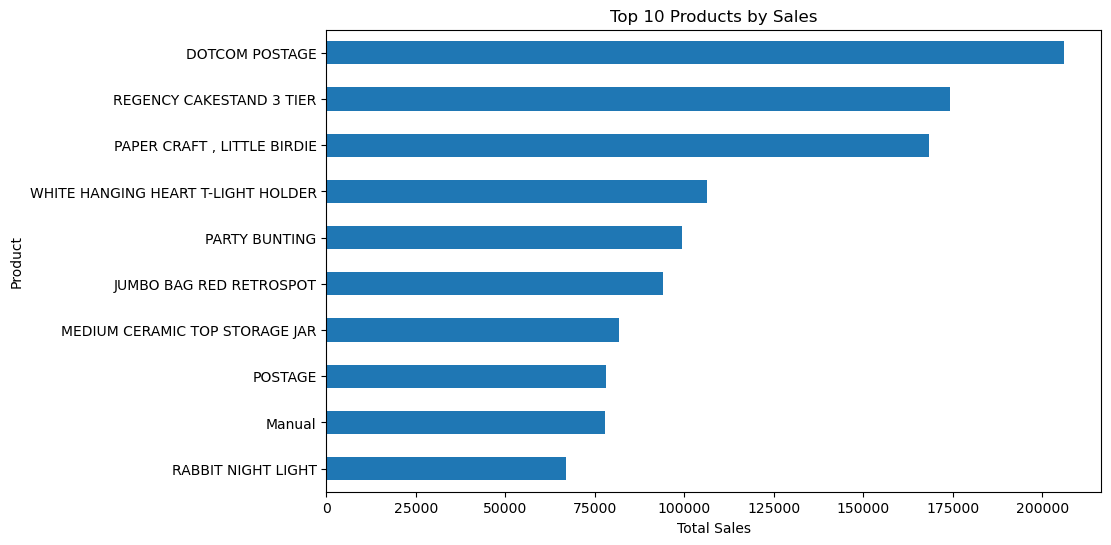

In [48]:
top_products = (
    df_clean.groupby('Description')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.show()

### 7.2 Top 10 Countries by Sales

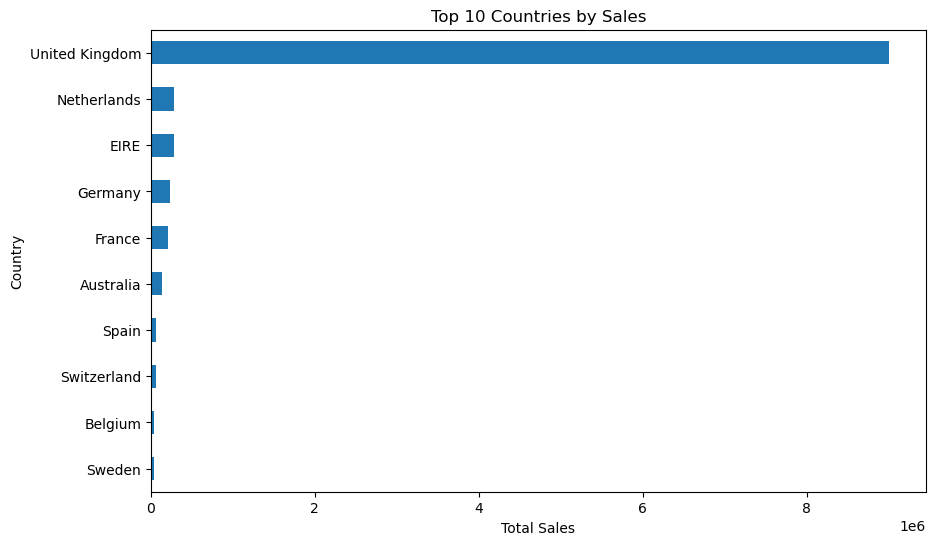

In [49]:
top_countries = (
    df_clean.groupby('Country')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
top_countries.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Country')
plt.show()

### 7.3 Monthly Sales Trend

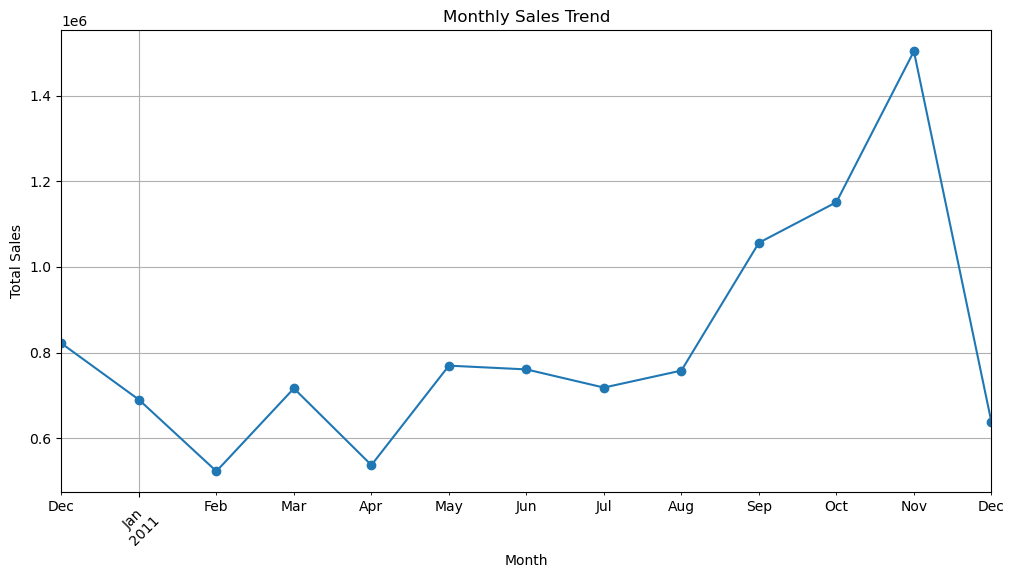

In [50]:
monthly_sales = (
    df_clean.groupby('Month')['Sales']
    .sum()
)

plt.figure(figsize=(12, 6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### 7.4 Sales Distribution

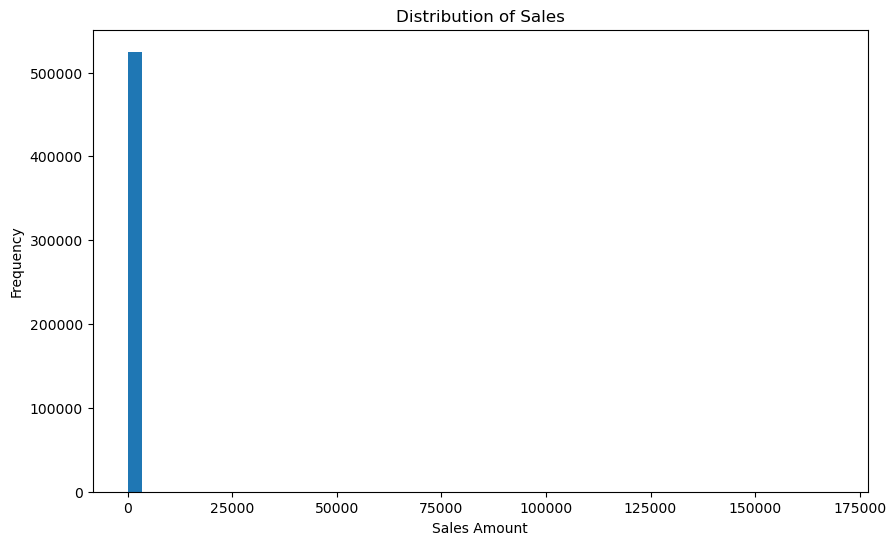

In [51]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean['Sales'], bins=50)

plt.title('Distribution of Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')

plt.show()

### 7.5 Quantity Distribution 

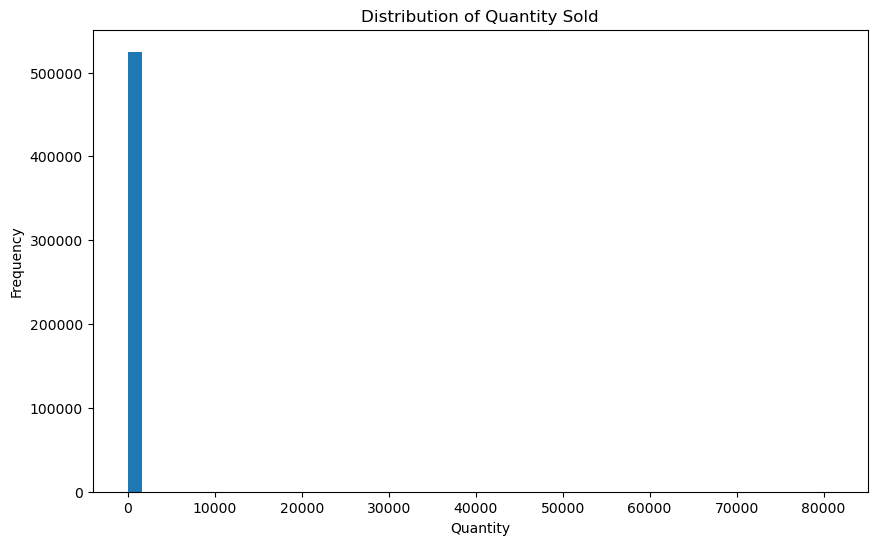

In [52]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean['Quantity'], bins=50)

plt.title('Distribution of Quantity Sold')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.show()

### 7.6 Unit Price Distribution

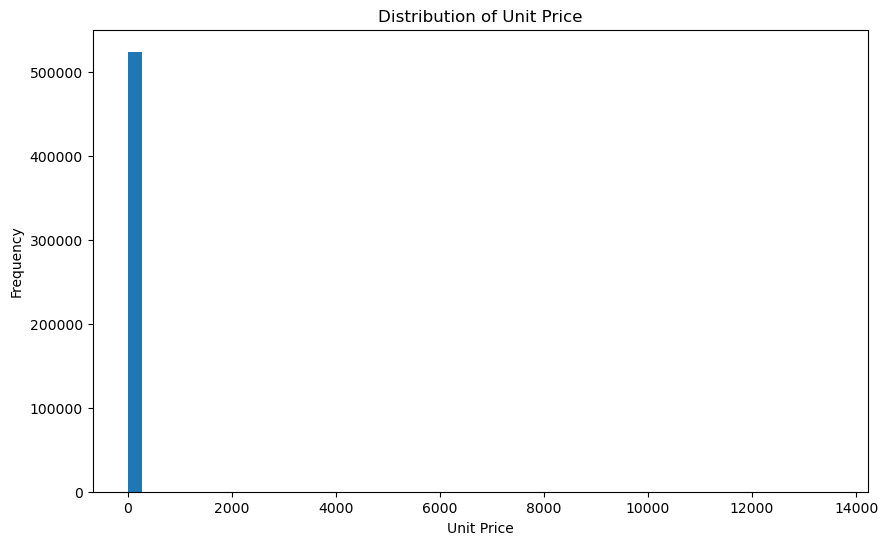

In [53]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean['UnitPrice'], bins=50)

plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')

plt.show()

### 7.7 Quantity Box Plot

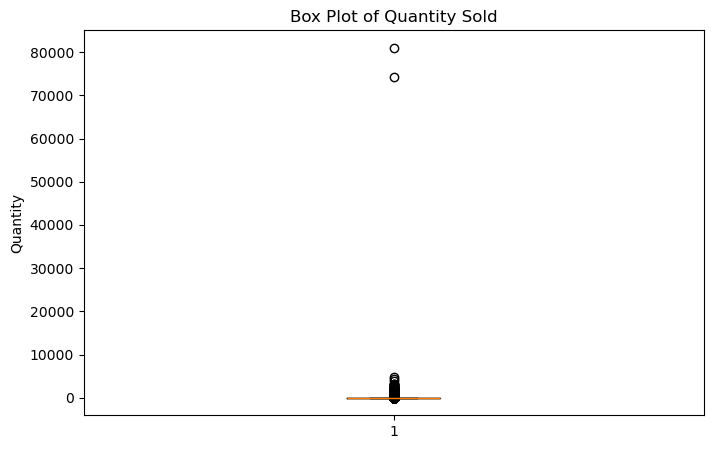

In [54]:
plt.figure(figsize=(8, 5))

plt.boxplot(df_clean['Quantity'])

plt.title('Box Plot of Quantity Sold')
plt.ylabel('Quantity')

plt.show() 

### 7.8 Unit Price Box Plot

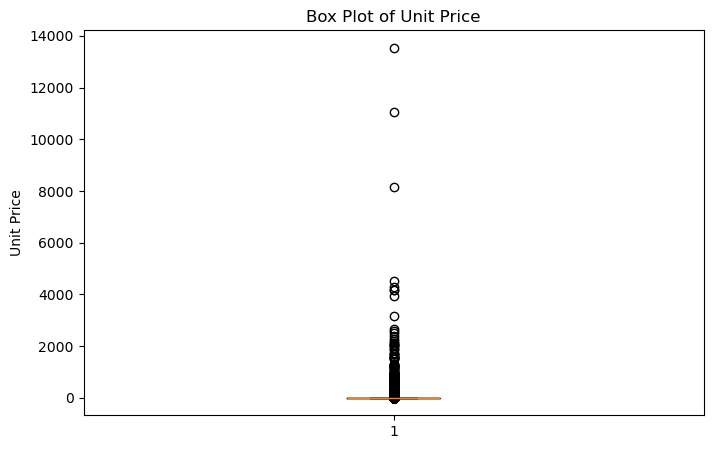

In [55]:
plt.figure(figsize=(8, 5))

plt.boxplot(df_clean['UnitPrice'])

plt.title('Box Plot of Unit Price')
plt.ylabel('Unit Price')

plt.show()

### 7.9 Sales Box Plot

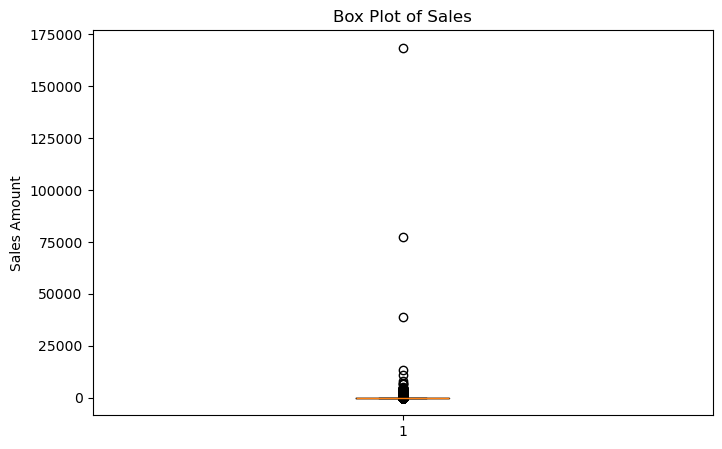

In [56]:
plt.figure(figsize=(8, 5))

plt.boxplot(df_clean['Sales'])

plt.title('Box Plot of Sales')
plt.ylabel('Sales Amount')

plt.show()

### 7.10 Top 10 Products by Quantity Sold

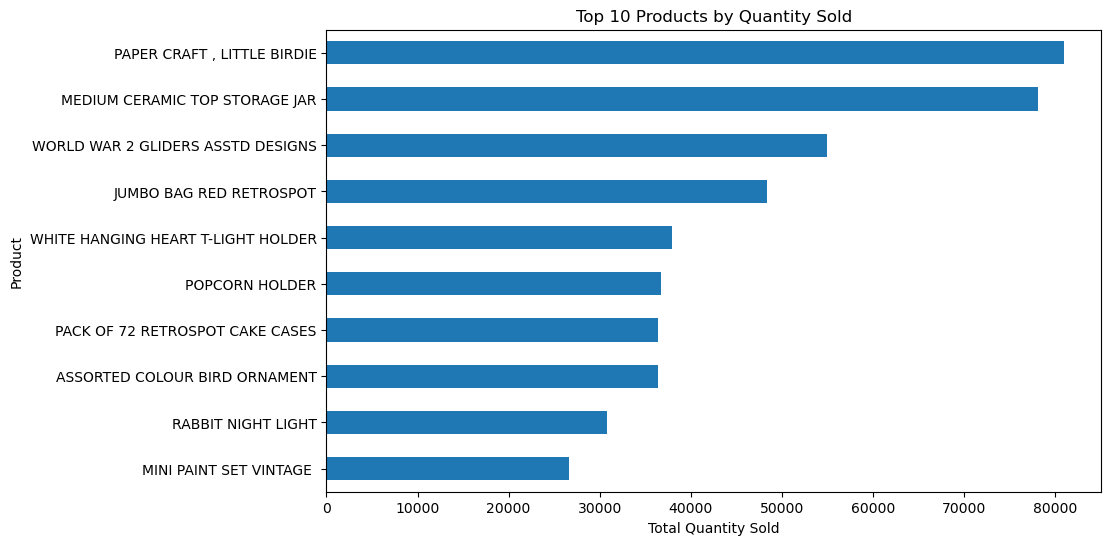

In [57]:
top_quantity_products = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_quantity_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')

plt.show()

### 7.11 Top 10 Countries by Number of Transactions

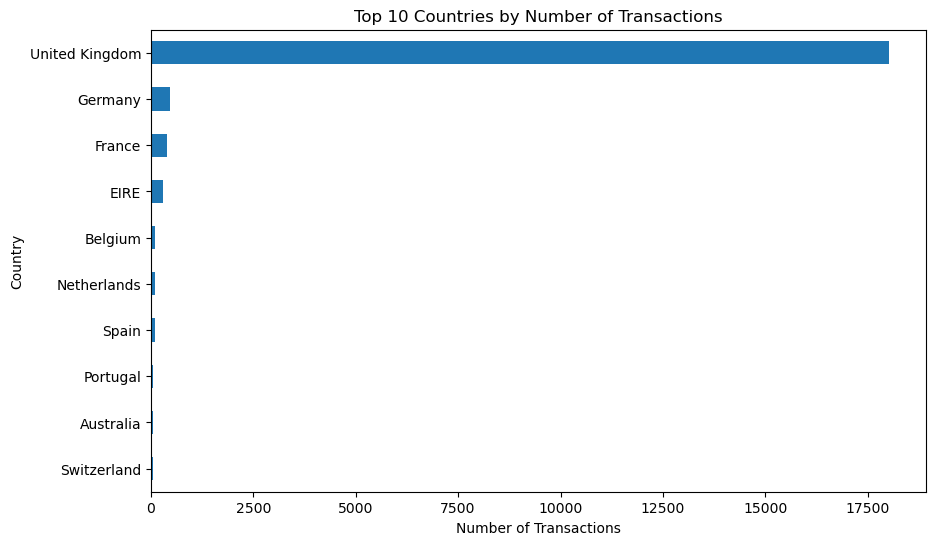

In [58]:
top_countries_orders = (
    df_clean.groupby('Country')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_countries_orders.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')

plt.show()

### 7.12 Top 10 Products by Number of Orders

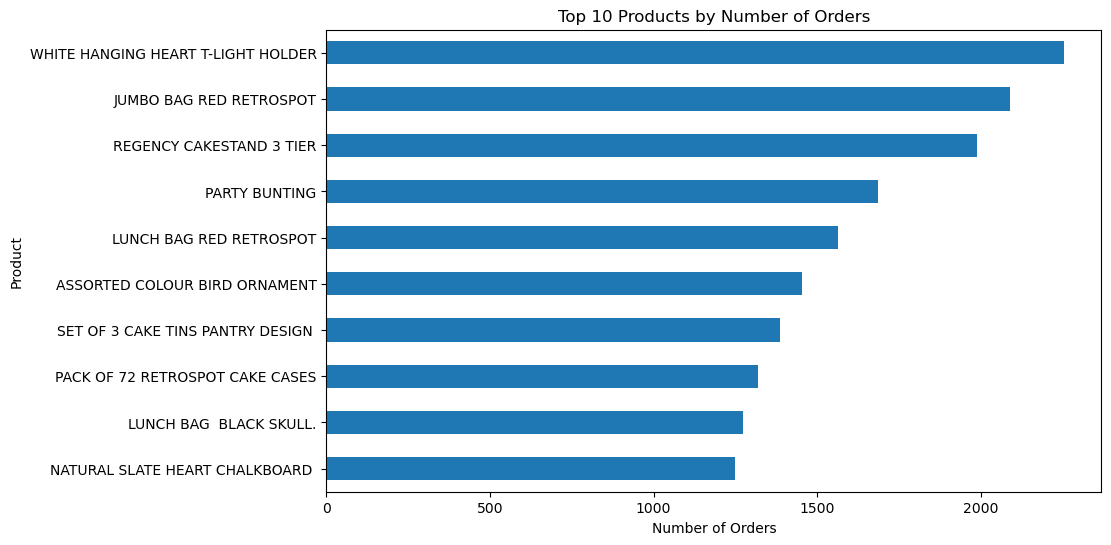

In [59]:
top_products_orders = (
    df_clean.groupby('Description')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_products_orders.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Product')

plt.show()

### 7.13 Top 10 Countries by Number of Transactions

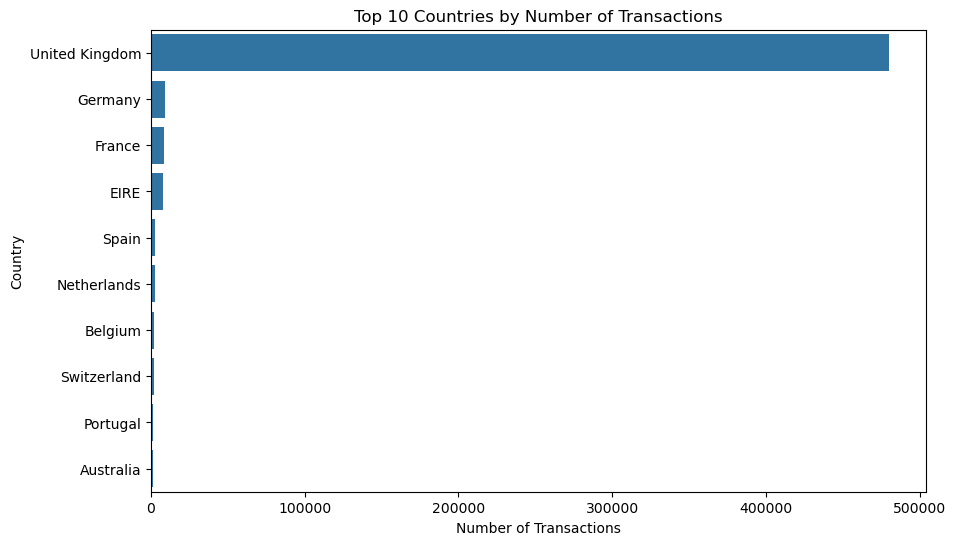

In [60]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_clean,
    y='Country',
    order=df_clean['Country'].value_counts().head(10).index
)

plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')

plt.show()

### 7.14 Top 10 Products by Number of Orders

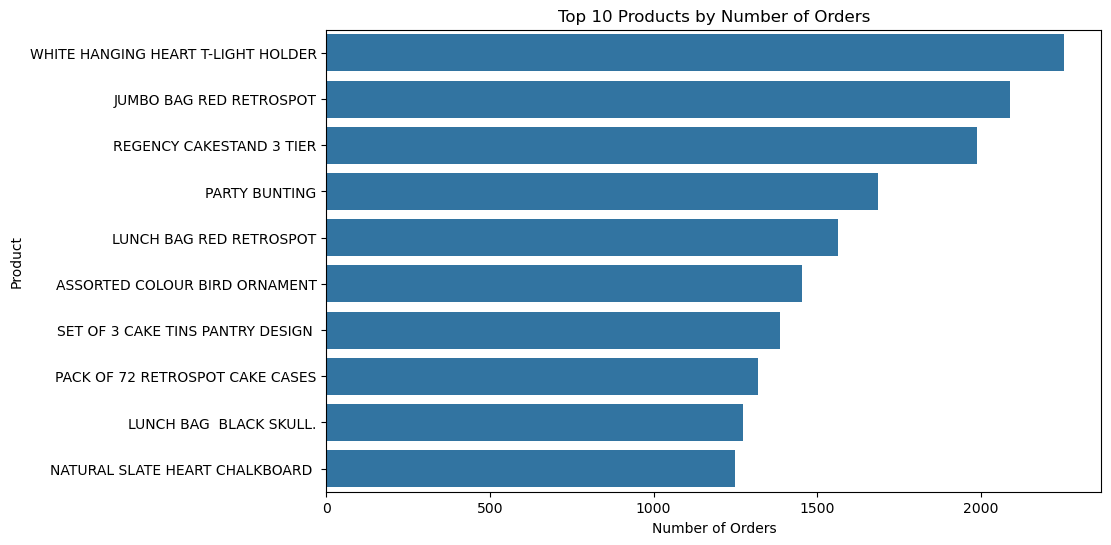

In [61]:
plt.figure(figsize=(10, 6))

top_products = (
    df_clean.groupby('Description')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Top 10 Products by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Product')

plt.show()

### 7.15 Unit Price vs Quantity Sold

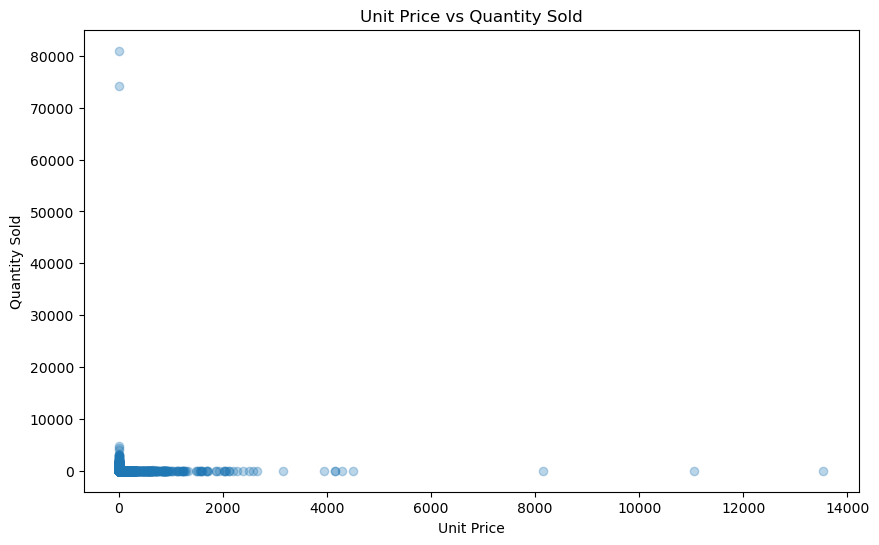

In [62]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean['UnitPrice'],
    df_clean['Quantity'],
    alpha=0.3
)

plt.title('Unit Price vs Quantity Sold')
plt.xlabel('Unit Price')
plt.ylabel('Quantity Sold')

plt.show()

### 7.16 Quantity vs Sales

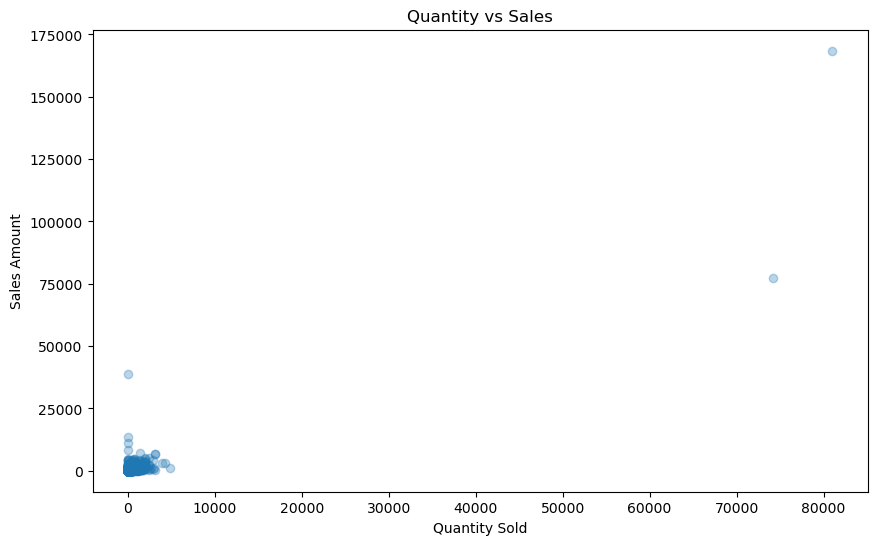

In [63]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean['Quantity'],
    df_clean['Sales'],
    alpha=0.3
)

plt.title('Quantity vs Sales')
plt.xlabel('Quantity Sold')
plt.ylabel('Sales Amount')

plt.show()

### 7.17 Correlation Heatmap

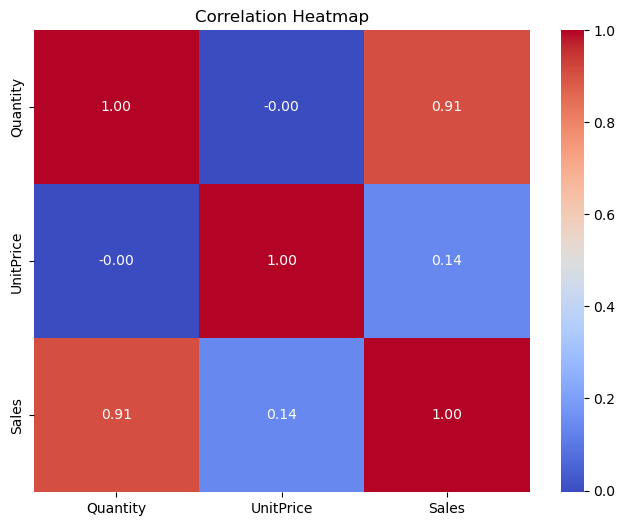

In [64]:
correlation = df_clean[['Quantity', 'UnitPrice', 'Sales']].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

### 7.18 Top 10 Customers by Total Sales

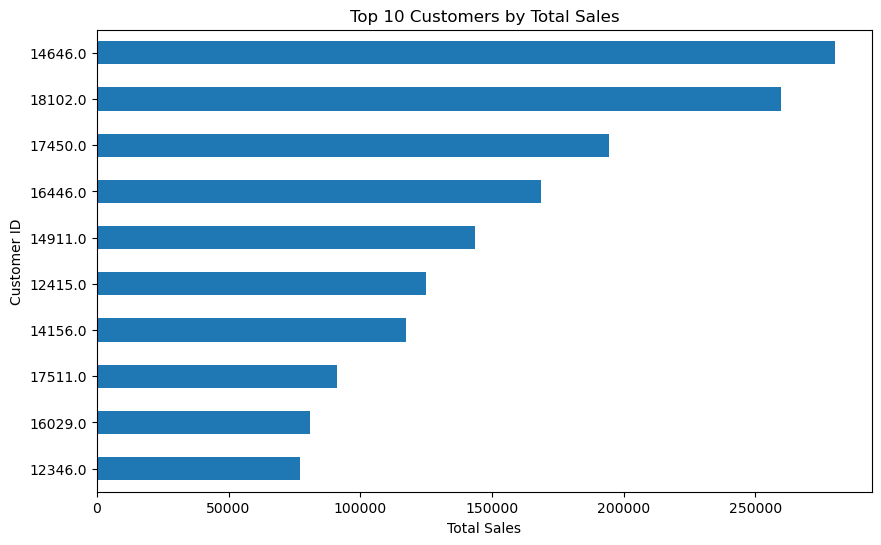

In [65]:
top_customers = (
    df_clean.dropna(subset=['CustomerID'])
    .groupby('CustomerID')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_customers.sort_values().plot(kind='barh')

plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer ID')

plt.show()

### 7.19 Weekly Sales Trend

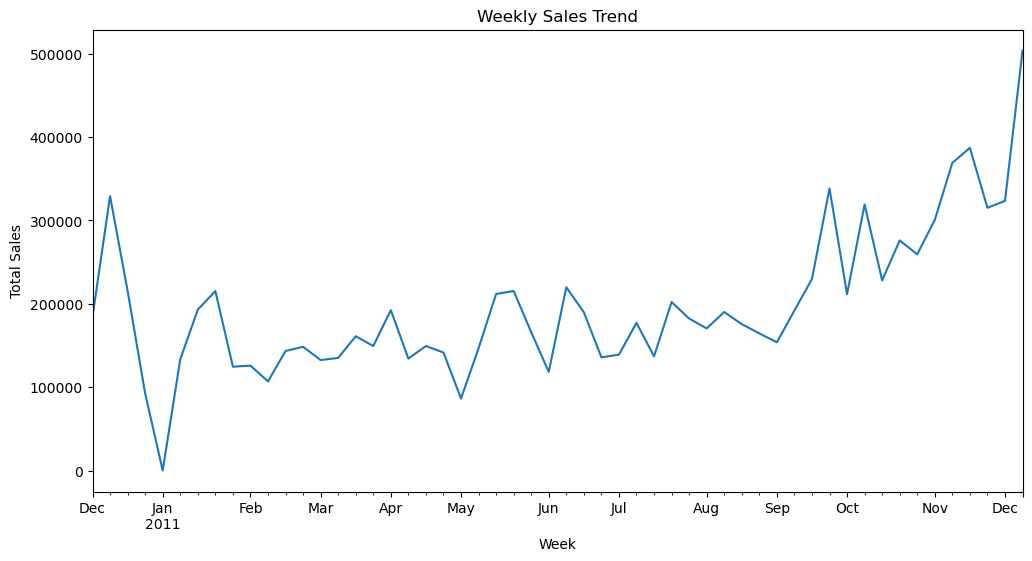

In [81]:
weekly_sales = (
    df_clean
    .set_index('InvoiceDate')['Sales']
    .resample('W')
    .sum()
)

plt.figure(figsize=(12, 6))

weekly_sales.plot()

plt.title('Weekly Sales Trend')
plt.xlabel('Week')
plt.ylabel('Total Sales')

plt.show()

### 7.20 Top 10 Countries by Average Transaction Value

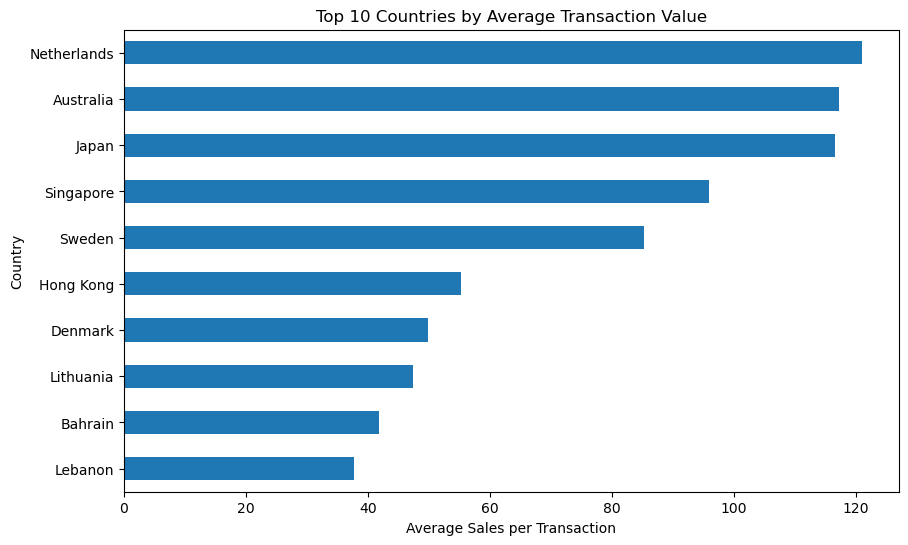

In [82]:
avg_sales_country = (
    df_clean.groupby('Country')['Sales']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

avg_sales_country.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Average Transaction Value')
plt.xlabel('Average Sales per Transaction')
plt.ylabel('Country')

plt.show()

## 8. Business Metrics

In [83]:
invoice_sales = (
    df_clean.groupby('InvoiceNo')['Sales']
    .sum()
)
aov = invoice_sales.mean()
print("Average Order Value:", round(aov, 2))

Average Order Value: 533.17


In [67]:
cancelled_count = df['InvoiceNo'].astype(str).str.startswith('C').sum()
total_transactions = len(df)

cancellation_percentage = (cancelled_count / total_transactions) * 100

print("Cancelled Transactions:", cancelled_count)
print("Total Transactions:", total_transactions)
print("Cancellation Percentage:", round(cancellation_percentage, 2), "%")

Cancelled Transactions: 9251
Total Transactions: 535187
Cancellation Percentage: 1.73 %


## 10. Outliner Analysis

In [69]:
Q1 = df_clean['Quantity'].quantile(0.25)
Q3 = df_clean['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

quantity_outliers = df_clean[
    (df_clean['Quantity'] < lower_limit) |
    (df_clean['Quantity'] > upper_limit)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Quantity Outliers:", len(quantity_outliers))

Q1: 1.0
Q3: 11.0
IQR: 10.0
Lower Limit: -14.0
Upper Limit: 26.0
Number of Quantity Outliers: 27111


In [70]:
Q1_price = df_clean['UnitPrice'].quantile(0.25)
Q3_price = df_clean['UnitPrice'].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

price_outliers = df_clean[
    (df_clean['UnitPrice'] < lower_price) |
    (df_clean['UnitPrice'] > upper_price)
]

print("Q1:", Q1_price)
print("Q3:", Q3_price)
print("IQR:", IQR_price)
print("Lower Limit:", lower_price)
print("Upper Limit:", upper_price)
print("Number of Unit Price Outliers:", len(price_outliers))

Q1: 1.25
Q3: 4.13
IQR: 2.88
Lower Limit: -3.0700000000000003
Upper Limit: 8.45
Number of Unit Price Outliers: 37827


In [71]:
Q1_sales = df_clean['Sales'].quantile(0.25)
Q3_sales = df_clean['Sales'].quantile(0.75)

IQR_sales = Q3_sales - Q1_sales

lower_sales = Q1_sales - 1.5 * IQR_sales
upper_sales = Q3_sales + 1.5 * IQR_sales

sales_outliers = df_clean[
    (df_clean['Sales'] < lower_sales) |
    (df_clean['Sales'] > upper_sales)
]

print("Q1:", Q1_sales)
print("Q3:", Q3_sales)
print("IQR:", IQR_sales)
print("Lower Limit:", lower_sales)
print("Upper Limit:", upper_sales)
print("Number of Sales Outliers:", len(sales_outliers))

Q1: 3.9
Q3: 17.700000000000003
IQR: 13.800000000000002
Lower Limit: -16.800000000000004
Upper Limit: 38.400000000000006
Number of Sales Outliers: 42624


In [73]:
total_sales = df_clean['Sales'].sum()
total_quantity = df_clean['Quantity'].sum()
total_orders = df_clean['InvoiceNo'].nunique()
unique_customers = df_clean['CustomerID'].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Quantity Sold:", total_quantity)
print("Total Orders:", total_orders)
print("Unique Customers:", unique_customers)
print("Average Order Value:", round(total_sales / total_orders, 2))

Total Sales: 10642110.8
Total Quantity Sold: 5572420
Total Orders: 19960
Unique Customers: 4338
Average Order Value: 533.17


In [74]:
monthly_sales = df_clean.groupby('Month')['Sales'].sum()

print("Highest Sales Month:")
print(monthly_sales.idxmax(), "=", round(monthly_sales.max(), 2))

print("\nLowest Sales Month:")
print(monthly_sales.idxmin(), "=", round(monthly_sales.min(), 2))

Highest Sales Month:
2011-11 = 1503866.78

Lowest Sales Month:
2011-02 = 522545.56


In [75]:
print("Highest:",monthly_sales.idxmax())
print("lowest:",monthly_sales.idxmin())

Highest: 2011-11
lowest: 2011-02


## 11. Key Insights

1. The cleaned dataset generated total sales of approximately 10.64 million from 19,960 orders.

2. The analysis identified 4,338 unique customers, with an average order value of 533.17.

3. November 2011 recorded the highest monthly sales of 1,503,866.78, while February 2011 recorded the lowest monthly sales of 522,545.56.

4. The cancellation rate was 1.73%, based on 9,251 cancelled transactions out of 535,187 original transactions.

5. Several products appeared repeatedly among the highest-selling, highest-quantity, and most frequently ordered products, indicating strong customer demand for these items.

6. A small group of customers generated particularly high total sales, indicating the presence of high-value customers.

7. The box plots and IQR analysis identified potential outliers in Quantity, UnitPrice, and Sales. These values were retained because they may represent genuine bulk or high-value transactions.

8. The sales trends showed variation across both monthly and weekly periods, indicating that sales performance changes over time.

## 12. Business Recommendations

1. Focus inventory planning on frequently ordered and high-demand products to reduce the possibility of stock shortages.

2. Monitor high-value customers and develop strategies to encourage repeat purchases and customer retention.

3. Investigate the reasons behind cancelled transactions and identify ways to reduce cancellations.

4. Use monthly and weekly sales trends to improve inventory and promotional planning during high-demand periods.

5. Investigate unusually high quantities, prices, and sales values to distinguish genuine bulk transactions from possible data-entry errors.

6. Analyze product performance regularly to identify products that generate high sales as well as products with consistently strong demand.

## 13. Conclusion

This exploratory data analysis provided insights into e-commerce sales,
product demand, customer purchasing behavior, transaction trends, and
cancellations.

The analysis identified high-performing products, important customer
segments, sales trends, and potential outliers. These findings can help
support better inventory planning, customer retention, and sales
decision-making.